# **pyNamo-EGT Tutorial**

This notebook introduces the main pyNamo-EGT workflow: define a game, plot its replicator-dynamics phase portrait, inspect equilibria, and customize publication-quality figures.

The package focuses on low-dimensional games where the state space can be visualized directly.

## 1. Setup and interactive widget

Import the main pyNamo modules and configure Matplotlib's widget backend. The widget backend allows interactive rotation of 3D figures in Jupyter notebooks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import game
import dynamics
import analysis
import drawer
import examples
import interactive

%config InlineBackend.figure_format = 'svg'
%matplotlib widget


The widget is useful for quick exploration of the built-in examples. Use `%matplotlib widget` in the setup cell if you want to rotate 3D figures interactively.

The default settings are chosen to work reasonably well across different examples, but no single set of visual parameters is optimal for every game. For teaching or publication figures, users will often want to adjust trajectory starting points, integration time, colors, arrows, vector fields, speed fields, or the 3D viewing angle.

In [2]:
plt.close("all")
interactive.launch_replicator_widget()

## 2. Mathematical Model

For a game with state vector $x$, pyNamo studies the replicator vector field

$$
\dot{x} = F(x).
$$

For a symmetric one-population game with payoff matrix $A$, the replicator equation is

$$
\dot{x}_i = x_i \left((Ax)_i - x^\top A x\right).
$$

The state remains in the simplex

$$
\Delta = \left\{x \in \mathbb{R}^n : x_i \ge 0, \sum_i x_i = 1\right\}.
$$

For asymmetric games, pyNamo uses one replicator equation per player/population. The payoff to each pure strategy is computed against the current mixed strategies of the other players. To keep this tutorial focused on usage, we do not introduce the full multi-index notation here; see standard references on multi-population replicator dynamics for the formal definition.

## 3. First Plot In One Line

The main plotting function is `drawer.phase_portrait`. It accepts a `game.Game` object and chooses the appropriate state space automatically.

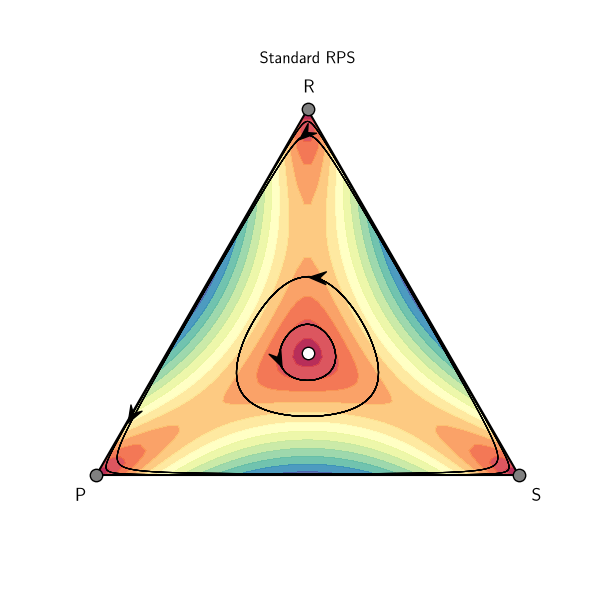

In [3]:
fig, ax = drawer.phase_portrait(examples.games.standard_rps)
plt.show()

`drawer.phase_portrait` returns two standard Matplotlib objects:

```python
fig, ax = drawer.phase_portrait(...)
```

pyNamo relies on Matplotlib for plotting. This means that figures created by pyNamo can be customized, modified, and saved using ordinary Matplotlib commands.

`fig` is the full figure. You use it when you want to save the figure or adjust figure-level settings.

`ax` is the axes object containing the phase portrait. You use it when you want to modify the plot itself, for example by changing the title, adding annotations, or drawing extra lines.

For example:

```python
fig.savefig("standard_rps.svg", bbox_inches="tight")
ax.set_title("My custom title")
```

Users who want finer control over the final appearance of figures can use the standard Matplotlib documentation as a reference.

## 4. pyNamo's game catalog

We have defined a small list of built-in example games that live in `examples.games`. You can access them by attribute, by name, or by game class.

In [15]:
examples.games.names()

['good_rps',
 'hawk_dove_retaliator',
 'standard_rps',
 'coordination_123',
 'pure_coordination',
 'repeated_pd_tft_allc_alld',
 'matching_pennies',
 'two_player_hawk_dove',
 'battle_of_the_sexes',
 'stag_hunt',
 'rps_with_twin',
 'chaotic_four_strategy_game',
 'ownership_game',
 'coordination_cube',
 'cyclic_mismatching_pennies',
 'cyclic_matching_pennies']

In [16]:
g = examples.games.ownership_game

g.describe()

# Equivalent lookup:
# examples.games("battle_of_the_sexes")
# examples.games.by_class("2P2S")

Ownership Game
--------------
Game class: 2P4S
Symmetric: True

Description:
Classical Hawk-Dove ownership game with Bourgeois and Anti-Bourgeois strategies.

Illustrates:
Ownership conventions, Bourgeois/Anti-Bourgeois equilibria, and asymmetric contest logic.

Parameters:
resource value v = 2, fighting cost c = 3.

Reference:
Maynard Smith & Parker (1976); see also Mesterton-Gibbons & Sherratt (2014).

Reference note:
Standard derived one-shot ownership game; Mesterton-Gibbons & Sherratt provide a modern treatment of Bourgeois and Anti-Bourgeois conventions.

Strategy labels:
['Hawk', 'Dove', 'Bourgeois', 'Anti-Bourgeois']

Player strategy labels:
[['Hawk', 'Dove', 'Bourgeois', 'Anti-Bourgeois']]

Player labels:
['Population']

Payoff data:
[[-0.5   2.    0.75  0.75]
 [ 0.    1.    0.5   0.5 ]
 [-0.25  1.5   1.    0.25]
 [-0.25  1.5   0.25  1.  ]]


## 5. Defining Your Own Game

### 2-player 3-strategy game

For symmetric two-player games, pass a single payoff matrix.

/Users/slimane/Documents/GitHub/pyNamo/analysis.py:654: ComplexWarning: Casting complex values to real discards the imaginary part
  basis = np.asarray(basis, dtype=float)


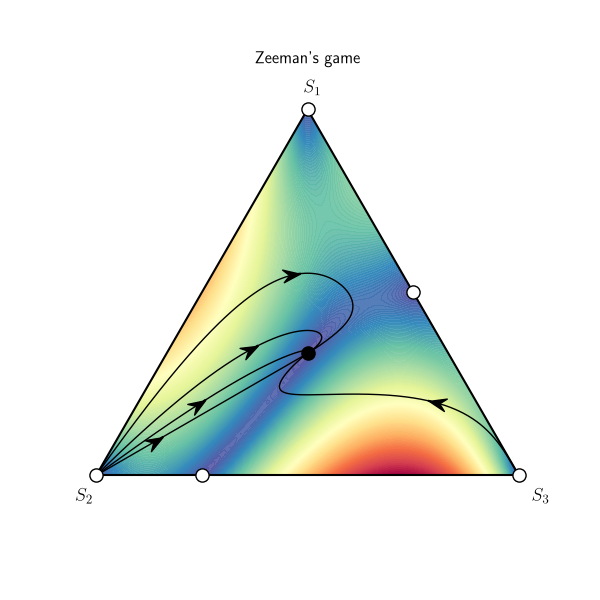

In [20]:
import numpy as np
import matplotlib.pyplot as plt

#Reproducing the example from Alexander (2023; Fig.16).
zeeman_like_game = game.Game(
    "Zeeman's game",
    np.array([
        [1, 1, 1],
        [0, 0, 3],
        [2, 1, 0],
    ], dtype=float),
    strategy_labels=["$S_1$", "$S_2$", "$S_3$"],
)

fig, ax = drawer.phase_portrait(
    zeeman_like_game,
    starts=[
        [0.10, 0.80],
        [0.20, 0.65],
        [0.35, 0.45],
        [0.55, 0.25],
        [0.2, 0.10],
    ],
    tmax=80,
    trajectory_arrows=[0.001],
    trajectory_color="black",
    trajectory_linewidth=1.0,
    speed_cmap=plt.cm.Spectral_r,
    speed_grid=80,
    speed_levels=200,
    sink_color="black",
    saddle_color="white",
    source_color="white",
    equilibrium_size=90,
)

plt.show()

### 2-player / 2-strategy game

To define a custom asymmetric 2-player / 2-strategy games (`2P2S` in pyNamo nomenclature), you should provide one payoff matrix per player.

Both matrices are indexed by the same action profiles: rows are player 1's strategies and columns are player 2's strategies. The first matrix gives player 1's payoff; the second matrix gives player 2's payoff.

The `2P2S` game class can also represent symmetric games studied as two-population dynamics. For example, the game catalog includes the two-population Hawk-Dove game as `examples.games.two_player_hawk_dove`.

If you define a custom symmetric game using the `2P2S` representation, player 2's payoff matrix should be the transpose of player 1's payoff matrix. This is because both matrices are written using the same action-profile convention: rows for player 1, columns for player 2.

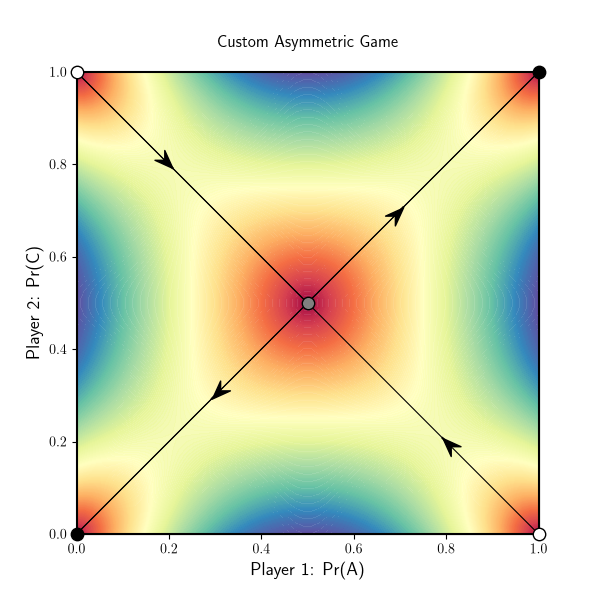

In [8]:
custom_asymmetric_game = game.Game(
    "Custom Asymmetric Game",
    (
        # Player 1 payoff matrix.
        # Rows: Player 1 strategies.
        # Columns: Player 2 strategies.
        np.array([
            [3, 0],
            [1, 2],
        ], dtype=float),

        # Player 2 payoff matrix.
        # This is not the transpose of player 1's matrix, so the game is asymmetric.
        # The indexing convention is still the same:
        # rows = player 1 strategies, columns = player 2 strategies.
        np.array([
            [2, 1],
            [0, 3],
        ], dtype=float),
    ),
    player_strategy_labels=[
        ["A", "B"],
        ["C", "D"],
    ],
    player_labels=["Player 1", "Player 2"],
    symmetric=False,
)

fig, ax = drawer.phase_portrait(
    custom_asymmetric_game,
    starts=[
        [0.2, 0.8],
        [0.8, 0.2],
        [0.3, 0.3],
        [0.7, 0.7],
    ],
    tmax=40,
    trajectory_arrows=[0.001],
    speed_cmap=plt.cm.Spectral,
    speed_levels=200,
)

plt.show()

### 3-player / 2-strategy game

For `3P2S` games, pyNamo represents three players or populations, each with two strategies. This representation can be used for genuinely asymmetric games, but also for symmetric games studied with one state variable per player/population.

Provide one payoff tensor per player.

All three tensors are indexed by the same action profiles:

$$
A^{(p)}_{i,j,k}
$$

where $p$ is the player receiving the payoff, $i$ is player 1's strategy, $j$ is player 2's strategy, and $k$ is player 3's strategy.

Thus:

$$
A^{(1)}_{i,j,k}
$$

is player 1's payoff at action profile $(i, j, k)$,

$$
A^{(2)}_{i,j,k}
$$

is player 2's payoff at the same action profile, and

$$
A^{(3)}_{i,j,k}
$$

is player 3's payoff at the same action profile.

The state is:

$$
(x,y,z)
$$

where each coordinate is the probability that the corresponding player uses their first listed strategy.

/Users/slimane/Documents/GitHub/pyNamo/analysis.py:161: DegenerateEquilibriumWarning: Degenerate equilibrium solutions detected: SymPy returned a parametric/non-isolated solution set. Non-isolated equilibrium sets are not plotted; isolated equilibria are still shown when they can be identified.
  raw_equilibria = dynamics.compute_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/drawer.py:1204: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibility, unstable equilibria are drawn with the source color and returned in the source bucket.
  plot_equilibria(


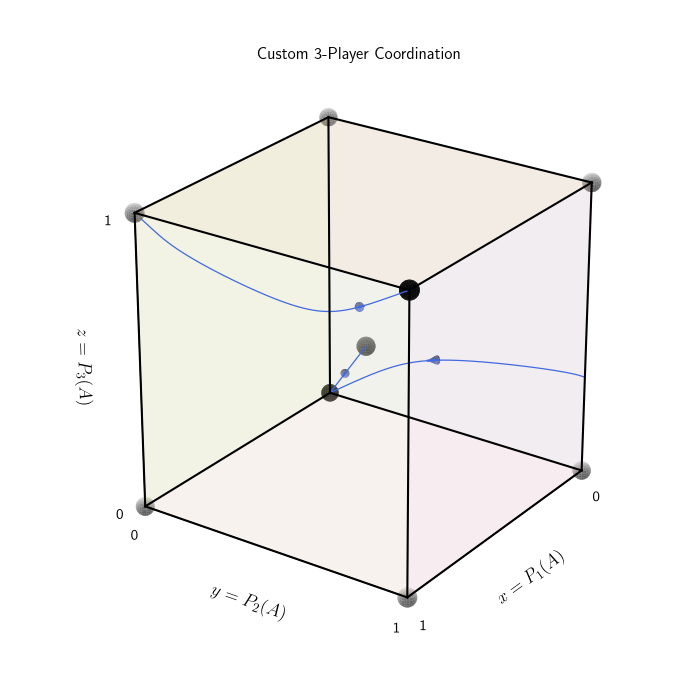

In [9]:
coordination_tensor = np.zeros((2, 2, 2), dtype=float)

for i in (0, 1):
    for j in (0, 1):
        for k in (0, 1):
            if i == j == k:
                coordination_tensor[i, j, k] = 1.0

custom_3p2s_coordination = game.Game(
    "Custom 3-Player Coordination",
    (
        # The same tensor is used for all three players.
        # Substantively, this is a symmetric coordination game.
        # We still use the 3P2S representation because we want one
        # state variable per player/population.
        coordination_tensor,
        coordination_tensor,
        coordination_tensor,
    ),
    player_strategy_labels=[
        ["A", "B"],
        ["A", "B"],
        ["A", "B"],
    ],
    player_labels=["Player 1", "Player 2", "Player 3"],
    strategy_labels=[
        "$x = P_1(A)$",
        "$y = P_2(A)$",
        "$z = P_3(A)$",
    ],
    symmetric=False,
)

fig, ax = drawer.phase_portrait(
    custom_3p2s_coordination,
    figsize=(7, 7),
    view_elev=25,
    view_azim=35,
    show_faces=True,
    face_alpha=0.14,
    starts=[
        [0.2, 0.2, 0.2],
        [0.8, 0.7, 0.8],
        [0.3, 0.6, 0.4],
    ],
    tmax=40,
    trajectory_arrows=[0.001],
    trajectory_color="royalblue",
    trajectory_linewidth=0.9,
)

plt.show()

## 6. Coordinate Conventions

For `2P3S` games with strategy labels `[A, B, C]`, a state vector equal to

$$
x = \begin{pmatrix}0.2 \\ 0.3 \\ 0.5\end{pmatrix}
$$

means $20\%$ strategy `A`, $30\%$ strategy `B`, and $50\%$ strategy `C`.

For `2P2S` asymmetric games, a state vector `[x, y]` means that player 1 uses its first listed strategy with probability $x$, and player 2 uses its first listed strategy with probability $y$. Note that since the game is asymmetric it is possible that $x+y>1$. The only constraint is that both $x \in [0,1]$ and $y \in [0,1]$.

### Initial Conditions

The `starts` argument specifies the initial conditions of the trajectories. It is a list whose entries are themselves lists:

```python
starts=[
    [0.2, 0.4],
    [0.7, 0.1],
]
```

Each inner list is one initial condition. Therefore, the length of `starts` determines the number of trajectories.

The number of coordinates in each initial condition depends on the game class.

For `2P2S` games, each initial condition has two coordinates:

$$
[x,y]
$$

where $x$ is the probability that player 1 uses its first listed strategy, and $y$ is the probability that player 2 uses its first listed strategy.

For `3P2S` games, each initial condition has three coordinates:

$$
[x,y,z]
$$

where each coordinate is the probability that the corresponding player uses its first listed strategy.

For symmetric `2P3S` games, the full state is:

$$
(x_1,x_2,x_3)
$$

but only the first two coordinates are passed:

$$
[x_1,x_2]
$$

The third coordinate is inferred as:

$$
x_3 = 1 - x_1 - x_2.
$$

For symmetric `2P4S` games, only the first three coordinates are passed:

$$
[x_1,x_2,x_3]
$$

The fourth coordinate is inferred as:

$$
x_4 = 1 - x_1 - x_2 - x_3.
$$

This reduced-coordinate convention keeps the plotted state space two-dimensional for `2P3S` games and three-dimensional for `2P4S` games.

## 7. Speed Fields, Vector Fields, And Trajectories

A speed field shows the norm of the vector field at each point:

$$
\text{speed}(x) = \lVert F(x) \rVert.
$$

A vector field shows local direction. Trajectories show realized paths from chosen initial conditions.

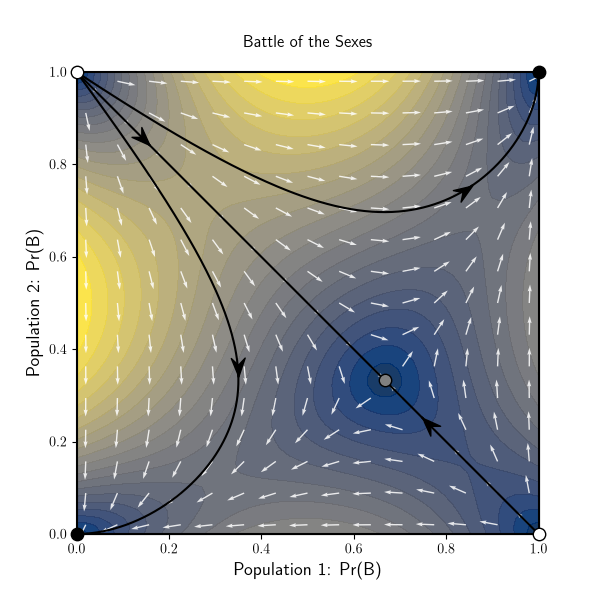

In [10]:
fig, ax = drawer.phase_portrait(
    examples.games.battle_of_the_sexes,
    starts=[
        [0.15, 0.85],
        [0.35, 0.35],
        [0.75, 0.25],
        [0.85, 0.75],
    ],
    tmax=30,
    trajectory_arrows=[0.001],
    trajectory_color="black",
    trajectory_linewidth=1.5, #one can adjust the trajectory line width to make it more visible or thinner, depending on preference.
    show_speed=True,
    speed_cmap=plt.cm.cividis, #one can use any matplotlib colormap, e.g., plt.cm.plasma, plt.cm.viridis, plt.cm.inferno, plt.cm.magma, plt.cm.cividis, plt.cm.coolwarm, plt.cm.Spectral, etc.
    speed_levels=20,
    show_vector_field=True,
    vector_color="white",
    vector_alpha=0.85,
)
plt.show()

## 8. Equilibria And Stability

pyNamo detects isolated rest points and classifies stability using the linearization restricted to admissible directions in the state space.

The table also reports static equilibrium concepts: Nash, ESS, and strict Nash.

In [11]:
analysis.equilibrium_table(examples.games.good_rps)

,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 0.0, 1.0]",saddle,False,False,False,"[2.0, -1.0]","[[1.0, 0.0], [0.0, 1.0]]",None
1,"[0.0, 1.0, 0.0]",saddle,False,False,False,"[2.0, -1.0]","[[0.0, 1.0], [0.707107, -0.707107]]",None
2,"[0.333333, 0.333333, 0.333333]",sink,True,True,False,"[(-0.166667+0.866025j), (-0.166667-0.866025j)]","[[0.707107, (-0.353553-0.612372j)], [0.707107,...",None
3,"[1.0, 0.0, 0.0]",saddle,False,False,False,"[-1.0, 2.0]","[[1.0, 0.0], [-0.707107, 0.707107]]",None


## 9. Stability Classification Used By pyNamo

For the admissible linearization, pyNamo uses the following conservative classification logic.

- **Sink**: all admissible eigenvalues have negative real part.
- **Source**: all admissible eigenvalues have positive real part.
- **Saddle**: admissible eigenvalues have both positive and negative real parts.
- **Center**: relevant eigenvalues have zero real part and nonzero imaginary part.
- **Unstable**: at least one admissible eigenvalue has positive real part, but zero or unsupported directions prevent distinguishing source from saddle.
- **Undetermined**: implemented criteria do not determine the case; pyNamo emits a warning.

Eigenvalue computations are numerical. Tiny imaginary parts below the internal tolerance are treated as numerical noise.

## 10. Degenerate Equilibrium Sets: Hawk-Dove-Retaliator

Some games have non-isolated equilibrium sets. pyNamo warns about these cases and does not automatically plot equilibrium manifolds.

The cell below shows how to manually inspect the Dove-Retaliator edge in the Hawk-Dove-Retaliator game from McElreath & Boyd (2007). The payoff matrix is:

$$
A =
\begin{array}{c|ccc}
 & H & D & R \\
\hline
H & \frac{v-c}{2} & v & \frac{v-c}{2} \\
D & 0 & \frac{v}{2} & \frac{v}{2} \\
R & \frac{v-c}{2} & \frac{v}{2} & \frac{v}{2}
\end{array}
$$

where $H$ is Hawk, $D$ is Dove, and $R$ is Retaliator.

In the code below, we use:

$$
v = 2, \qquad c = 3.
$$

With these values, the Dove-Retaliator edge is a continuum of rest points. The edge itself is invariant; the colors in the plot indicate transverse stability with respect to invasion by Hawk.

/Users/slimane/Documents/GitHub/pyNamo/analysis.py:161: DegenerateEquilibriumWarning: Degenerate equilibrium solutions detected: SymPy returned a parametric/non-isolated solution set. Non-isolated equilibrium sets are not plotted; isolated equilibria are still shown when they can be identified.
  raw_equilibria = dynamics.compute_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/drawer.py:743: InconclusiveStabilityWarning: Stability classification is inconclusive for equilibrium [0.0, 0.0, 1.0]: admissible linearization has eigenvalues with zero real part or unsupported eigendirections, and the implemented fallback did not establish asymptotic stability.
  result = analysis.analyze_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/drawer.py:1204: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibility, unstable equilibria are drawn with

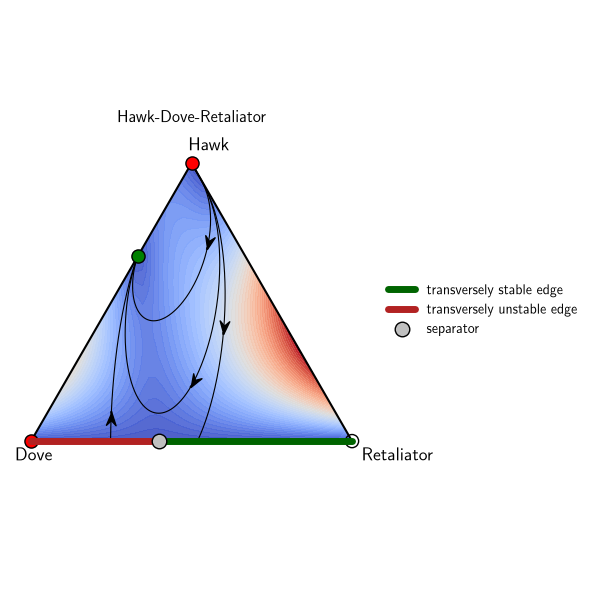

/Users/slimane/Documents/GitHub/pyNamo/analysis.py:161: DegenerateEquilibriumWarning: Degenerate equilibrium solutions detected: SymPy returned a parametric/non-isolated solution set. Non-isolated equilibrium sets are not plotted; isolated equilibria are still shown when they can be identified.
  raw_equilibria = dynamics.compute_equilibria(payoff_data)
/Users/slimane/Documents/GitHub/pyNamo/analysis.py:245: InconclusiveStabilityWarning: Stability classification is inconclusive for equilibrium [0.0, 0.0, 1.0]: admissible linearization has eigenvalues with zero real part or unsupported eigendirections, and the implemented fallback did not establish asymptotic stability.
  return analyze_equilibria(game).to_dataframe(ndigits=ndigits)


,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.666667, 0.333333, 0.0]",sink,True,True,False,"[-0.333333, -0.333333]","[[0.707107, -0.707107], [0.707107, -0.707107]]",NaN
1,"[1.0, 0.0, 0.0]",unstable,False,False,False,"[0.0, 0.5]","[[1.0, 0.0], [-0.707107, 0.707107]]",NaN
2,"[0.0, 1.0, 0.0]",unstable,False,False,False,"[0.0, 1.0]","[[0.0, 1.0], [0.707107, -0.707107]]",NaN
3,"[0.0, 0.0, 1.0]",undetermined,True,False,False,"[-1.5, 0.0]","[[1.0, 0.0], [0.0, 1.0]]",Stability classification is inconclusive for e...


In [12]:
g = examples.games.hawk_dove_retaliator
A = g.payoff_data

fig, ax = drawer.phase_portrait(
    g,
    starts=[
        [0.4, 0.2],
        [0.2, 0.4],
        [0.1, 0.7],
        [0.7, 0.1],
    ],
    tmax=120,
    trajectory_arrows=[0.001],
    trajectory_zorder=40,
    speed_cmap=plt.cm.coolwarm,
    speed_grid=50,
    speed_levels=50,
    sink_color="green",
    saddle_color="gold",
    source_color="red",
    equilibrium_size=90,
    equilibrium_zorder=45,
)

# On the Dove-Retaliator edge, x_Hawk = 0. Every point on this edge
# is a rest point because Dove and Retaliator receive identical payoffs
# against Dove/Retaliator mixtures. Transverse stability is determined by
# whether a rare Hawk has positive or negative growth.
dove_grid = np.linspace(0, 1, 1001)
rare_hawk_growth = []

for dove_share in dove_grid:
    state = np.array([0.0, dove_share, 1.0 - dove_share])
    payoff_hawk = A[0] @ state
    average_payoff = state @ A @ state
    rare_hawk_growth.append(payoff_hawk - average_payoff)

rare_hawk_growth = np.array(rare_hawk_growth)
stable_mask = rare_hawk_growth < 0
unstable_mask = rare_hawk_growth > 0


def plot_edge_segments(mask, color, label):
    idx = np.where(mask)[0]
    if idx.size == 0:
        return

    breaks = np.where(np.diff(idx) > 1)[0] + 1
    segments = np.split(idx, breaks)

    for segment in segments:
        d0 = dove_grid[segment[0]]
        d1 = dove_grid[segment[-1]]

        p0 = drawer.simplex_to_plane_2p3s(0.0, d0)
        p1 = drawer.simplex_to_plane_2p3s(0.0, d1)

        ax.plot(
            [p0[0], p1[0]],
            [p0[1], p1[1]],
            color=color,
            linewidth=5,
            zorder=50,
            solid_capstyle="round",
            label=label,
        )
        label = None


plot_edge_segments(stable_mask, "darkgreen", "transversely stable edge")
plot_edge_segments(unstable_mask, "firebrick", "transversely unstable edge")

# For the default v=2, c=3, the separator is at Dove share c/(v+c)=3/5.
separator_dove_share = 3 / 5
separator = drawer.simplex_to_plane_2p3s(0.0, separator_dove_share)
ax.scatter(
    separator[0],
    separator[1],
    s=110,
    color="silver",
    edgecolors="black",
    zorder=55,
    label="separator",
)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

analysis.equilibrium_table(g)

## 11. 2-Player / 2-Strategy Games

For `2P2S` games, pyNamo plots the unit square. The axes are the probabilities that each player uses their first listed strategy. This representation can be used for genuinely asymmetric games, but also for symmetric games studied as two-population dynamics.

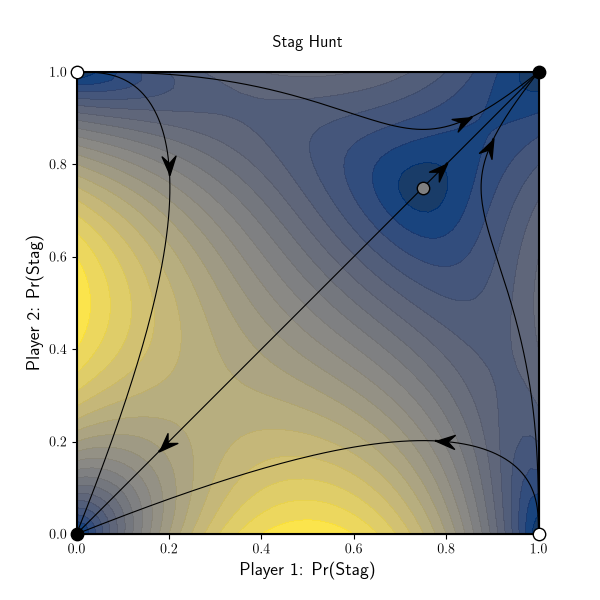

,Position,Stability Status,Nash,ESS,Strict Nash,Eigenvalues,Eigenvectors,Warning
0,"[0.0, 0.0]",sink,True,None,True,"[-3.0, -3.0]","[[1.0, 0.0], [0.0, 1.0]]",None
1,"[0.0, 1.0]",source,False,None,False,"[1.0, 3.0]","[[1.0, 0.0], [0.0, 1.0]]",None
2,"[0.75, 0.75]",saddle,True,None,False,"[0.75, -0.75]","[[0.707107, 0.707107], [-0.707107, 0.707107]]",None
3,"[1.0, 0.0]",source,False,None,False,"[3.0, 1.0]","[[1.0, 0.0], [0.0, 1.0]]",None
4,"[1.0, 1.0]",sink,True,None,True,"[-1.0, -1.0]","[[1.0, 0.0], [0.0, 1.0]]",None


In [13]:
fig, ax = drawer.phase_portrait(
    examples.games.stag_hunt,
    starts=[
        [0.2, 0.2],
        [0.2, 0.8],
        [0.8, 0.2],
        [0.8, 0.8],
        [0.85, 0.9],
        [0.9, 0.85]
    ],
    tmax=60,
    trajectory_arrows=[0.001],
    speed_cmap=plt.cm.cividis,
    speed_levels=20,
)
plt.show()

analysis.equilibrium_table(examples.games.stag_hunt)

## 12. 3D Examples

Colored faces are optional. They are useful in 3D state spaces when users want to emphasize the boundary structure.

/Users/slimane/Documents/GitHub/pyNamo/drawer.py:1204: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibility, unstable equilibria are drawn with the source color and returned in the source bucket.
  plot_equilibria(


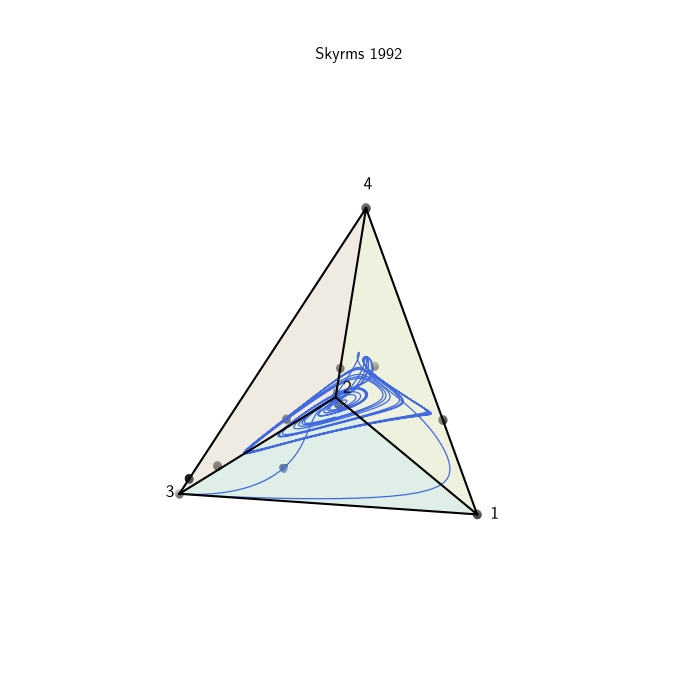

In [ ]:
fig, ax = drawer.phase_portrait(
    examples.games.ownership_game,
    figsize=(7, 7),
    view_elev=25,
    view_azim=35,
    show_faces=True,
    face_alpha=0.18,
    starts=[
        [0.22, 0.25, 0.25],
        [0.20, 0.20, 0.60],
    ],
    tmax=80,
    trajectory_arrows=[0.001],
    trajectory_color="royalblue",
    trajectory_linewidth=0.9,
    equilibrium_size=20,
)
plt.show()

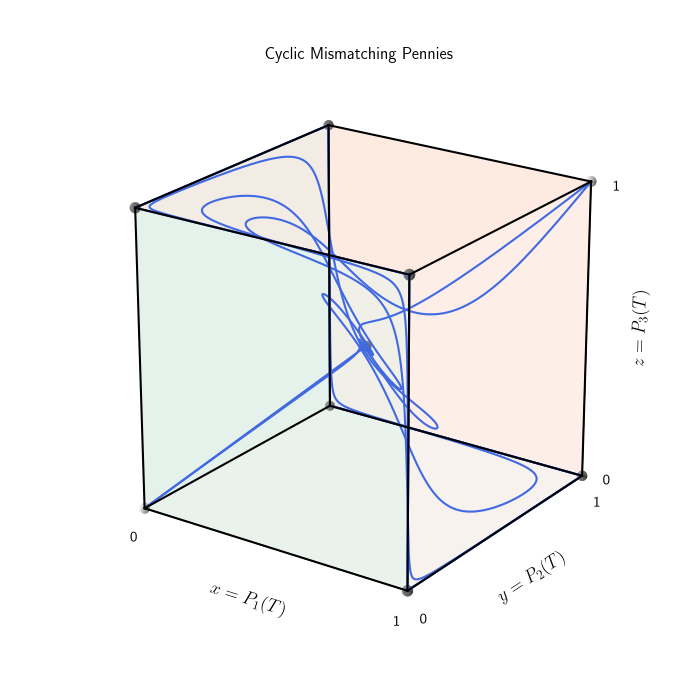

In [4]:
fig, ax = drawer.phase_portrait(
    examples.games.cyclic_mismatching_pennies,
    figsize=(7, 7),
    view_elev=22,
    view_azim=-55,
    show_faces=True,
    face_alpha=0.14,
    starts=[
        [0.52, 0.50, 0.48],
        [0.60, 0.50, 0.40],
        [0.70, 0.45, 0.35],
        [0.20, 0.65, 0.75],
    ],
    tmax=400,
    trajectory_arrows=[],
    trajectory_color="royalblue",
    trajectory_linewidth=1.5,
    equilibrium_size=25,
)
plt.show()

## 13. Saving Publication-Quality Figures

pyNamo returns standard Matplotlib objects. Save figures exactly as you would save any Matplotlib figure.

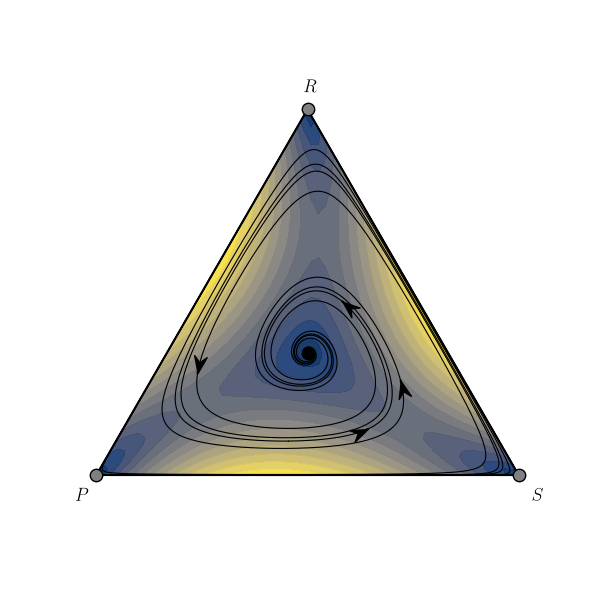

In [6]:
fig, ax = drawer.phase_portrait(
    examples.games.good_rps,
    speed_cmap=plt.cm.cividis,
    trajectory_color="black",
)

ax.set_title("")

fig.savefig("good_rps_replicator_dynamics.svg", bbox_inches="tight")
fig.savefig("good_rps_replicator_dynamics.pdf", bbox_inches="tight")
plt.show()

## 14. Full Parameter Customization

The two cells below deliberately tweak most user-facing parameters of `drawer.phase_portrait`. They are useful examples to copy from when preparing figures.

For the complete parameter documentation, use Python's `help` function:

```python
help(drawer.phase_portrait)
```

In some notebook frontends, abbreviated help such as `drawer.phase_portrait?` may truncate long docstrings.

In [17]:
help(drawer.phase_portrait)

Help on function phase_portrait in module drawer:

phase_portrait(game, *, fig=None, ax=None, figsize=(6, 6), view_elev=25, view_azim=35, xlabel=None, ylabel=None, zlabel=None, title_pad=18, starts=None, random_state=None, simplex_font_size=13, simplex_zorder=30, show_speed=True, speed_grid=60, speed_cmap=<matplotlib.colors.LinearSegmentedColormap object at 0x10b22ff50>, speed_levels=12, speed_zorder=10, show_vector_field=False, vector_grid=15, vector_margin=0.02, vector_color='black', vector_alpha=0.75, vector_length=0.04, vector_width=0.003, vector_zorder=15, vector_normalize=True, show_faces=False, face_colors=None, face_alpha=0.15, face_zorder=0, show_trajectories=True, trajectory_step=0.02, trajectory_arrows=None, tmax=45, trajectory_color='black', trajectory_linewidth=0.8, arrow_size=0.04, arrow_width=0.015, trajectory_zorder=20, show_equilibria=True, sink_color='black', saddle_color='gray', source_color='white', center_color=None, equilibrium_size=80, equilibrium_zorder=40)
    

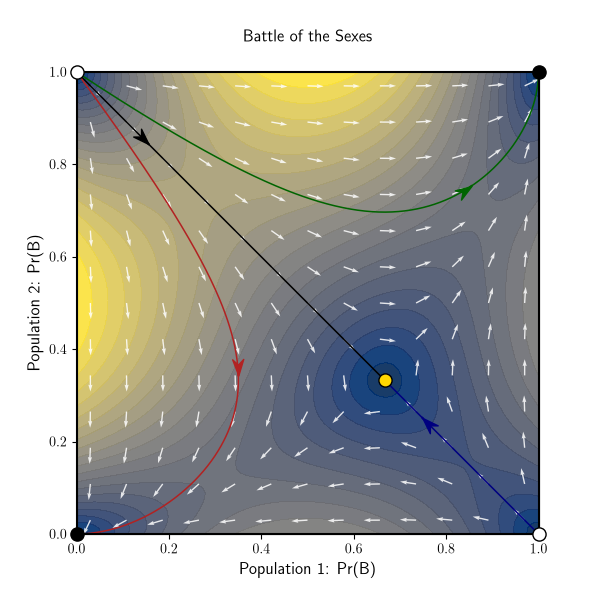

In [18]:
fig, ax = drawer.phase_portrait(
    examples.games.battle_of_the_sexes,
    figsize=(6, 6),
    xlabel="Population 1: Pr(B)",
    ylabel="Population 2: Pr(B)",
    title_pad=22,
    starts=[
        [0.15, 0.85],
        [0.35, 0.35],
        [0.75, 0.25],
        [0.85, 0.75],
    ],
    random_state=7,
    simplex_font_size=12,
    simplex_zorder=30,
    show_speed=True,
    speed_grid=80,
    speed_cmap=plt.cm.cividis,
    speed_levels=20,
    speed_zorder=5,
    show_vector_field=True,
    vector_grid=13,
    vector_margin=0.03,
    vector_color="white",
    vector_alpha=0.85,
    vector_length=0.035,
    vector_width=0.003,
    vector_zorder=15,
    vector_normalize=True,
    show_faces=False,
    show_trajectories=True,
    trajectory_step=0.015,
    trajectory_arrows=[0.001],
    tmax=30,
    trajectory_color=["black", "firebrick", "navy", "darkgreen"],
    trajectory_linewidth=1.1,
    arrow_size=0.035,
    arrow_width=0.012,
    trajectory_zorder=25,
    show_equilibria=True,
    sink_color="black",
    saddle_color="gold",
    source_color="white",
    center_color="tab:blue",
    equilibrium_size=90,
    equilibrium_zorder=40,
)
plt.show()

/Users/slimane/Documents/GitHub/pyNamo/drawer.py:1204: PlottingWarning: At least one equilibrium is classified as 'unstable': linearization proves it is not stable, but does not distinguish source from saddle. For plotting compatibility, unstable equilibria are drawn with the source color and returned in the source bucket.
  plot_equilibria(


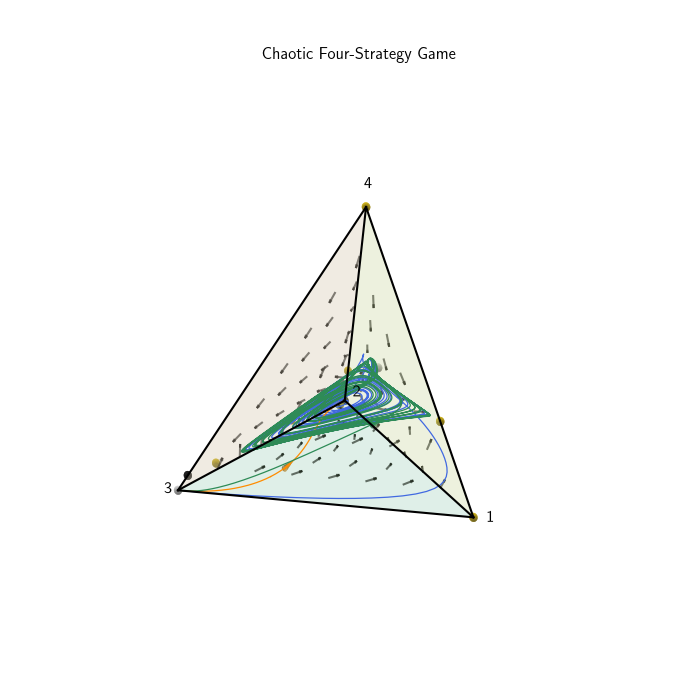

In [18]:
fig, ax = drawer.phase_portrait(
    examples.games.chaotic_four_strategy_game,
    figsize=(7, 7),
    view_elev=24,
    view_azim=38,
    xlabel=None,
    ylabel=None,
    zlabel=None,
    title_pad=18,
    starts=[
        [0.22, 0.25, 0.25],
        [0.20, 0.20, 0.60],
        [0.45, 0.10, 0.20],
    ],
    random_state=12,
    simplex_font_size=12,
    simplex_zorder=30,
    show_speed=False,
    speed_grid=60,
    speed_cmap=plt.cm.Spectral,
    speed_levels=12,
    speed_zorder=10,
    show_vector_field=True,
    vector_grid=8,
    vector_margin=0.06,
    vector_color="black",
    vector_alpha=0.65,
    vector_length=0.04,
    vector_width=0.003,
    vector_zorder=15,
    vector_normalize=True,
    show_faces=True,
    face_colors=[
        "#9ecae1",
        "#fdd49e",
        "#a1d99b",
        "#fbb4b9",
    ],
    face_alpha=0.18,
    face_zorder=0,
    show_trajectories=True,
    trajectory_step=0.02,
    trajectory_arrows=[0.001],
    tmax=90,
    trajectory_color=["royalblue", "darkorange", "seagreen"],
    trajectory_linewidth=0.9,
    arrow_size=0.08,
    arrow_width=0.01,
    trajectory_zorder=25,
    show_equilibria=True,
    sink_color="black",
    saddle_color="gold",
    source_color="white",
    center_color="tab:blue",
    equilibrium_size=18,
    equilibrium_zorder=40,
)
plt.show()

## Appendix: Edge-Case Checks

The cells below are not part of the standard workflow and can be skipped on a first reading. They are compact stress tests for common ways users may push the API.

In [ ]:
# Turn plot layers on and off independently.
fig, ax = drawer.phase_portrait(
    examples.games.good_rps,
    show_speed=False,
    show_trajectories=False,
    show_vector_field=True,
    show_equilibria=True,
    vector_color="black",
)
plt.show()

In [ ]:
# Wrong number of trajectory colors should fail explicitly.
try:
    drawer.phase_portrait(
        examples.games.good_rps,
        starts=[[0.2, 0.2], [0.6, 0.2]],
        trajectory_color=["black"],
    )
except ValueError as err:
    print(err)

Expected 4 face colors, got 2.


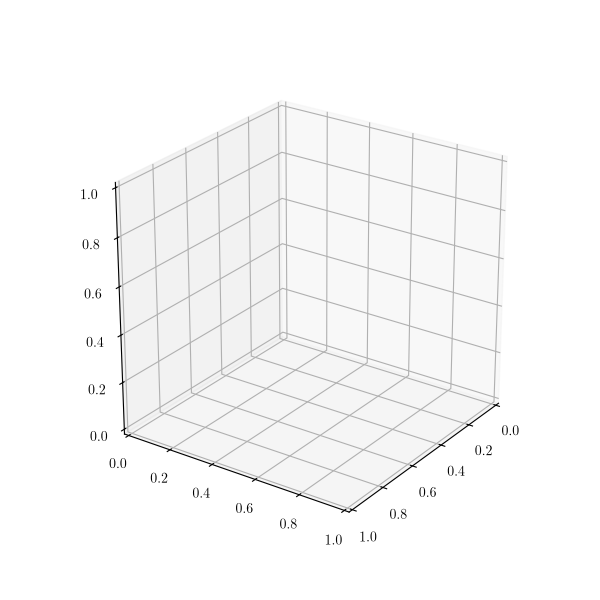

In [17]:
# Wrong number of 3D face colors should fail explicitly.
try:
    drawer.phase_portrait(
        examples.games.ownership_game,
        show_faces=True,
        face_colors=["lightblue", "khaki"],
        show_trajectories=False,
        show_equilibria=False,
    )
except ValueError as err:
    print(err)

In [ ]:
# Degenerate games should emit a warning and avoid reporting spurious
# isolated points embedded in an equilibrium continuum.
analysis.equilibrium_table(examples.games.repeated_pd_tft_allc_alld)